# Data Storytelling with Visualization (Instructor Version)

This notebook contains **suggested visualizations and instructor notes** for the student EDA notebook.

Teaching strategy:

1. Ask students to propose a visualization first.
2. Let them implement their idea.
3. Then compare with the suggested solution.

Dataset: Global Earthquakes (~23k records)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/plotly/datasets/master/earthquakes-23k.csv"
df = pd.read_csv(url)

df.head()

,Date,Latitude,Longitude,Magnitude
0,01/02/1965,19.246,145.616,6.0
1,01/04/1965,1.863,127.352,5.8
2,01/05/1965,-20.579,-173.972,6.2
3,01/08/1965,-59.076,-23.557,5.8
4,01/09/1965,11.938,126.427,5.8


# Question 1 — Magnitude Distribution

EDA Question:

How are earthquake magnitudes distributed?

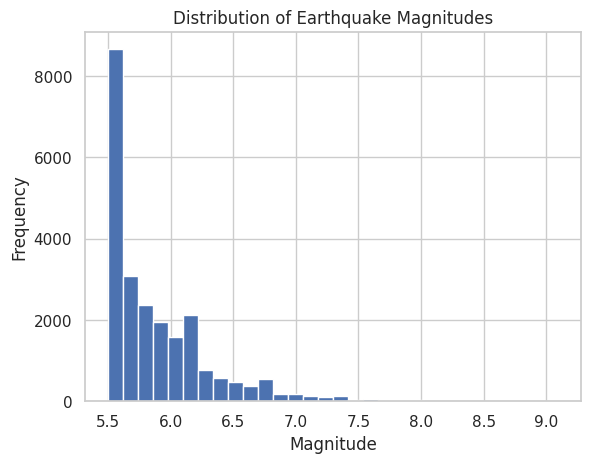

In [ ]:
plt.hist(df["Magnitude"], bins=30)
plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

Instructor note:

Most earthquakes cluster around **lower magnitudes (≈4–5)**.
Large earthquakes are rare but present.

# Question 2 — Detect Outliers
EDA Question:

Are there unusually large earthquakes in the dataset?


Suggested visualization: **Boxplot**

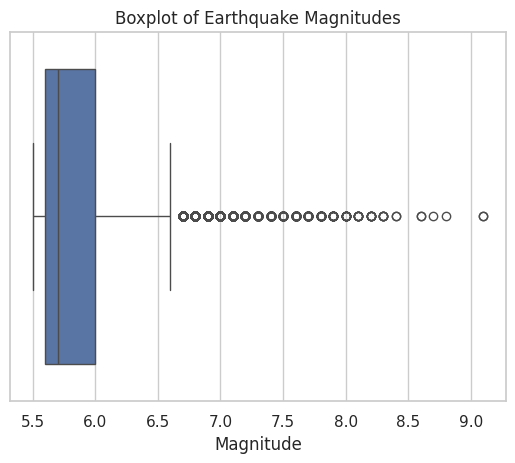

In [ ]:
sns.boxplot(x=df["Magnitude"])
plt.title("Boxplot of Earthquake Magnitudes")
plt.show()

Instructor note:

The boxplot reveals several **high magnitude outliers**.
These correspond to rare but powerful earthquakes.

# Question 3 — Earthquakes Over Time

EDA Question:

How does the number of earthquakes change across years?

Think about:

- What data transformation is needed?
- Which visualization works well for time-based patterns?

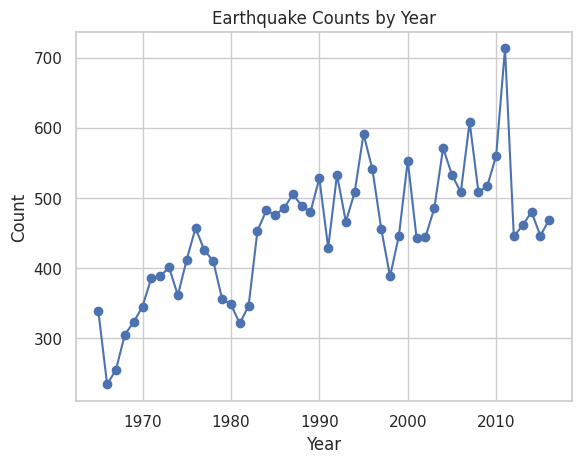

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format='mixed', utc=True)
df["Year"] = df["Date"].dt.year

year_counts = df.groupby("Year").size()

plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Earthquake Counts by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Instructor note:

Students should notice **fluctuations across years** rather than a simple linear trend.

# Question 4 — Average Magnitude Over Time

EDA Question:

Does the **average earthquake magnitude** change over time?

Think about:

- What summary statistic is needed?
- Should the visualization compare time periods?

Suggested visualization: **Line Chart**

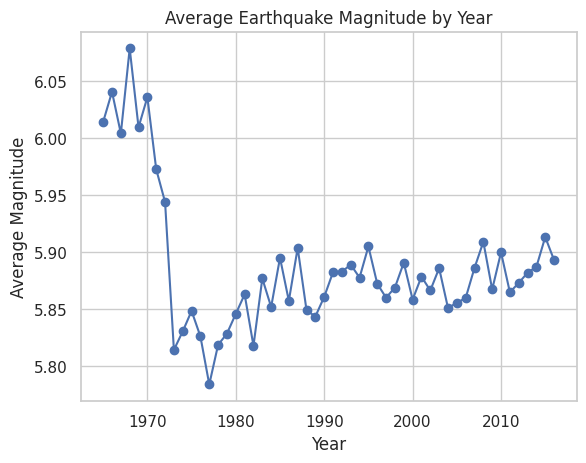

In [ ]:
avg_mag = df.groupby("Year")["Magnitude"].mean()

plt.plot(avg_mag.index, avg_mag.values, marker="o")
plt.title("Average Earthquake Magnitude by Year")
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.show()

# Question 5 — Monthly Comparison


EDA Question:

Which months have the highest earthquake counts?

Think about:

- How should the data be grouped?
- What visualization helps compare categories clearly?

Suggested visualization: **Bar Chart**

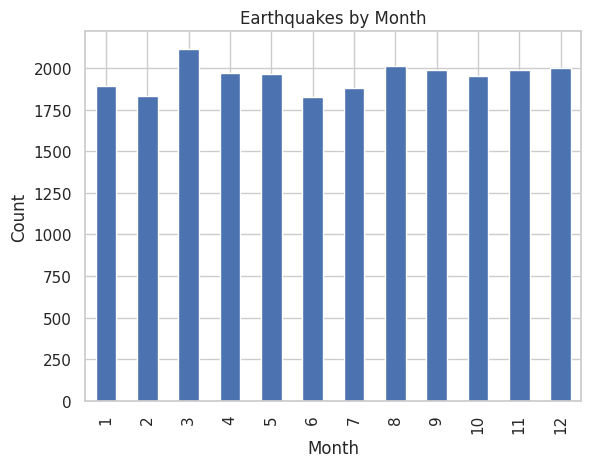

In [ ]:
df["Month"] = df["Date"].dt.month
month_counts = df.groupby("Month").size()

month_counts.plot(kind="bar")
plt.title("Earthquakes by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

Instructor note:

Monthly variation exists but strong seasonal patterns are not obvious.

# Question 6 — Hemisphere Comparison

EDA Question:

Do earthquakes occur more often in the Northern or Southern hemisphere?

Think about:

- How to derive hemisphere categories
- What comparison visualization works best

Suggested visualization: **Bar Chart**

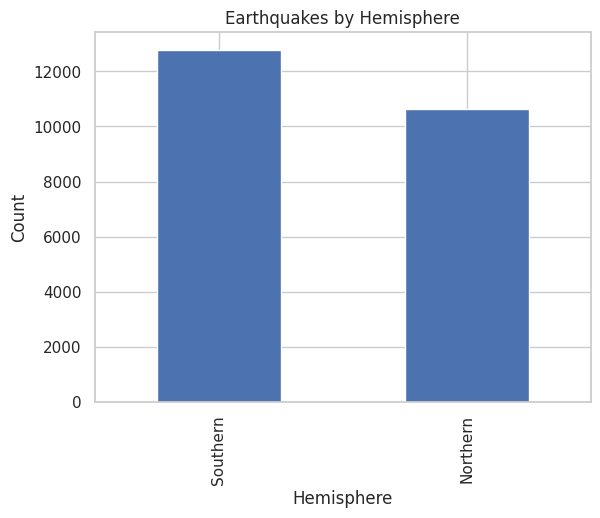

In [ ]:
df["Hemisphere"] = np.where(df["Latitude"] >= 0, "Northern", "Southern")

hemisphere_counts = df["Hemisphere"].value_counts()

hemisphere_counts.plot(kind="bar")
plt.title("Earthquakes by Hemisphere")
plt.ylabel("Count")
plt.show()

# Question 7 — Geographic Spread
EDA Question:

How are earthquakes distributed geographically across the world?

Think about:

- Which variables represent location?
- What visualization best represents geographic distribution?
Suggested visualization: **Scatter Plot**

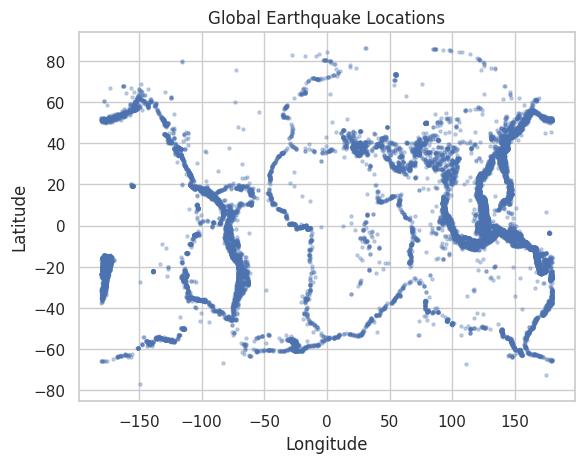

In [ ]:
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.3, s=5)
plt.title("Global Earthquake Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Question 8 — Relationship Between Latitude and Magnitude

EDA Question:

Is there a relationship between **latitude and magnitude**?

Think about:

- Are the variables numeric?
- What visualization helps reveal relationships between numeric variables?
Suggested visualization: **Scatter Plot**

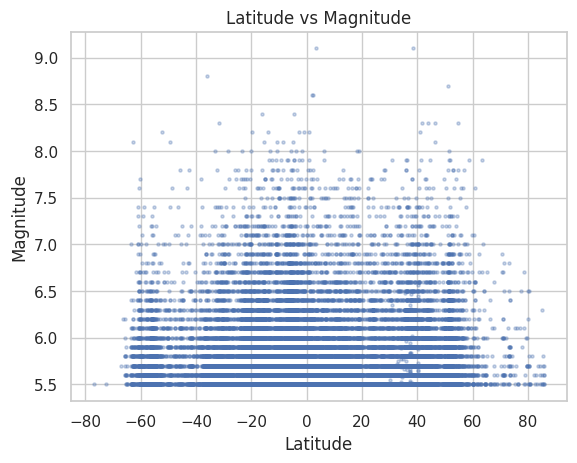

In [ ]:
plt.scatter(df["Latitude"], df["Magnitude"], alpha=0.3, s=5)
plt.title("Latitude vs Magnitude")
plt.xlabel("Latitude")
plt.ylabel("Magnitude")
plt.show()

Instructor note:

No strong linear relationship appears between latitude and magnitude.

# Question 9 — Year–Month Heatmap

EDA Question:

Are there year–month combinations with unusually high earthquake counts?

Think about:

- How to reshape the dataset
- What visualization can show two dimensions clearly

Suggested visualization: **Heatmap**

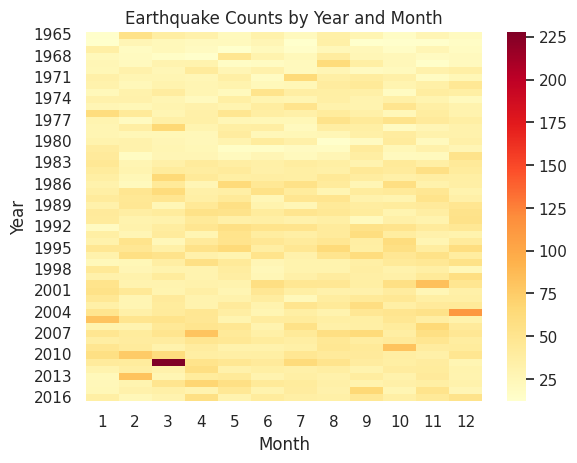

In [ ]:
heatmap_data = df.groupby(["Year","Month"]).size().unstack(fill_value=0)

sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Earthquake Counts by Year and Month")
plt.show()

Instructor note:

Heatmaps allow students to compare **two categorical dimensions simultaneously**.

# Question 10 — Map Visualization


EDA Question:

Where are earthquakes concentrated around the world?

Think about:

- How latitude and longitude should be visualized
- Whether marker color or size can represent magnitude

Suggested visualization: **Interactive Map**

In [ ]:
sample = df.sample(5000, random_state=1)

fig = px.scatter_geo(
    sample,
    lat="Latitude",
    lon="Longitude",
    color="Magnitude",
    size="Magnitude",
    projection="orthographic",
    title="Global Earthquake Map"
)

fig.show()

Instructor note:

Interactive maps are ideal for geographic storytelling.
Students often discover clusters near:

- Japan
- Indonesia
- Chile
- Alaska

# Example Data Story

Example narrative for class discussion:

Most earthquakes in the dataset have magnitudes between 4 and 5, with rare extreme events above magnitude 7.  
The number of earthquakes fluctuates across years but does not show a clear increasing trend.  
Geographically, earthquakes cluster strongly along tectonic plate boundaries.  
The Pacific Ring of Fire shows the highest concentration of events.  
Overall, the data demonstrates that earthquake occurrence is strongly linked to geological structure rather than seasonal patterns.